In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 日本語フォントの設定
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Hiragino Maru Gothic Pro', 'Hiragino Sans', 'Yu Gothic', 'Meirio', 'MS Gothic', 'Noto Sans CJK JP']

単回帰

【分析結果】
決定係数 (R^2): 0.1715
--------------------------------------------------


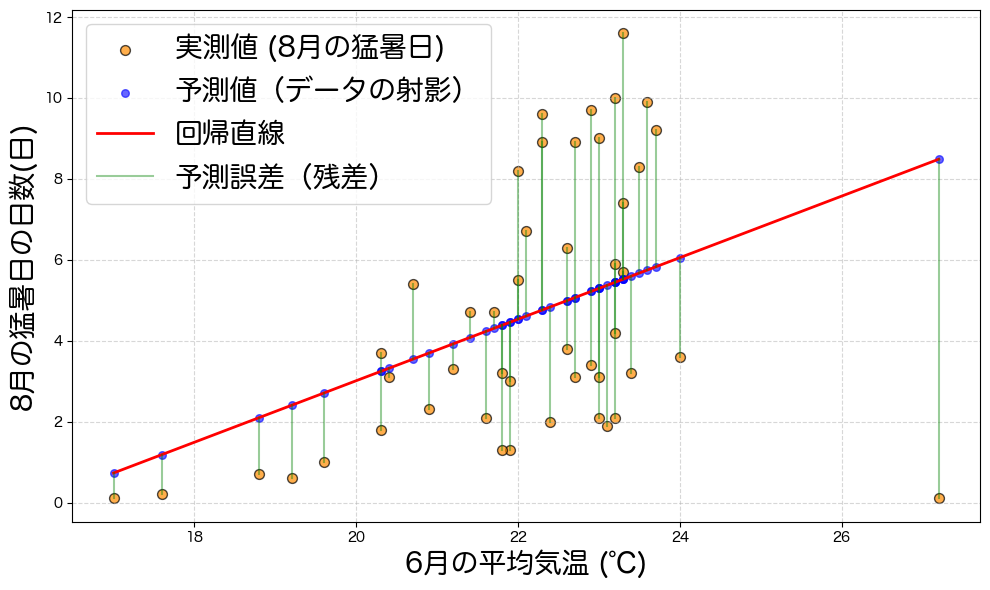

In [26]:
def simple_regression(x, y):
    xm = np.mean(x)
    ym = np.mean(y)
    sx2 = np.var(x)
    sxy = np.mean(x*y) - xm*ym
    a = sxy / sx2
    b = ym - a * xm
    yhat = a * x + b
    ssr = ((yhat - ym)**2).sum()
    sst = ((y - ym)**2).sum()
    R2 = ssr / sst
    return yhat, a, b, R2

def draw_lr(x, y, yhat):
    
    plt.figure(figsize=(10, 6), tight_layout=True)

    plt.scatter(x, y, color='darkorange', alpha=0.7, edgecolors='black', s=50, label='実測値 (8月の猛暑日)')
    
    plt.scatter(x, yhat, color='blue', alpha=0.6, s=30, label='予測値（データの射影）')

    plt.xlabel('6月の平均気温 (℃)', fontsize=20)
    plt.ylabel('8月の猛暑日の日数(日)', fontsize=20)

    idx = x.argsort()
    sx = x[idx]
    syhat = yhat[idx]

    plt.plot(sx, syhat, color='red', linewidth=2, label='回帰直線')

    for i in range(len(x)):
        xx = [x[i], x[i]]
        yy = [y[i], yhat[i]]        
        plt.plot(xx, yy, color='green', alpha=0.4, 
                 label='予測誤差（残差）' if i == 0 else None)

    plt.legend(fontsize=20)
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.show()


# ==========================================
# 2. データの前処理
# ==========================================
# データの読み込み
df = pd.read_csv('tem.csv', header=1, encoding='utf-8-sig')
df.columns = df.columns.str.strip()

df_june = df[df['月・年'] == '06月'].copy()
df_august = df[df['月・年'] == '08月'].copy()
#ここを変更する
df_june = df_june.rename(columns={'平均気温': '6月_平均気温'})

df_merge = pd.merge(
    df_june[['都道府県', '市', '6月_平均気温']],
    df_august[['都道府県', '市', '日最高気温35℃以上の日数']],
    on=['都道府県', '市']
)


# 数値型への変換と欠損値の除去
df_merge['6月_平均気温'] = pd.to_numeric(df_merge['6月_平均気温'], errors='coerce')
df_merge['日最高気温35℃以上の日数'] = pd.to_numeric(df_merge['日最高気温35℃以上の日数'], errors='coerce')
df_clean = df_merge.dropna(subset=['6月_平均気温', '日最高気温35℃以上の日数'])

# numpy配列に変換
X = df_clean['6月_平均気温'].values
Y = df_clean['日最高気温35℃以上の日数'].values

# ==========================================
# 3. 分析の実行と関数の呼び出し
# ==========================================
# 計算処理
yhat, a, b, R2 = simple_regression(X, Y)

print("【分析結果】")
print(f"決定係数 (R^2): {R2:.4f}")
print("-" * 50)

# ★ 分離した描画関数を呼び出す（引数は x, y, yhat の3つだけ）
draw_lr(X, Y, yhat)

多項式回帰

a = [ 1.41859969e+03 -1.76396357e+02  7.25101977e+00 -9.83560610e-02]
R2 = 0.3241


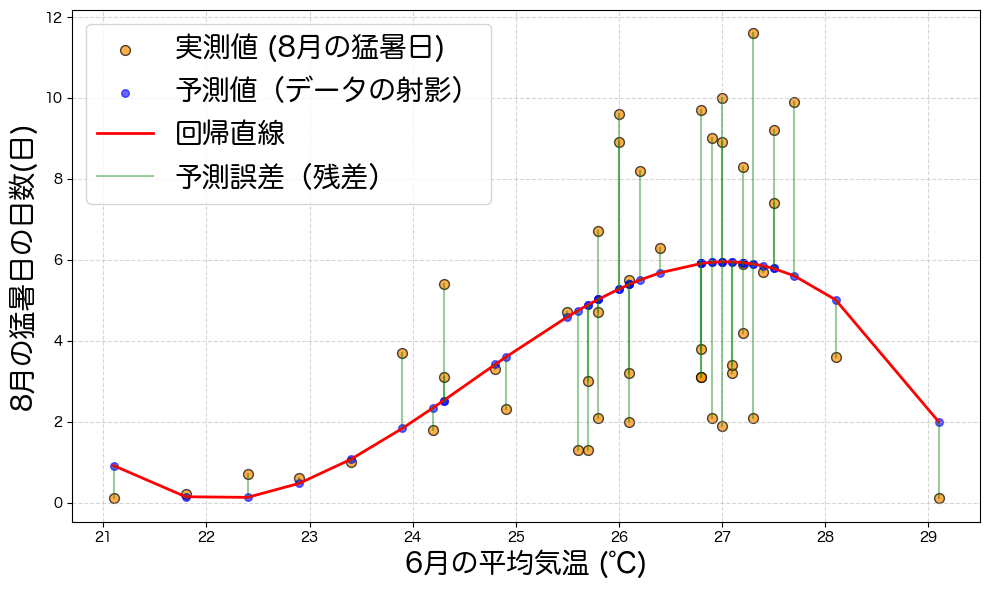

In [27]:
def make_design_matrix(x, d):
    """ 
    多項式回帰のためのデザイン行列を生成する関数
    引数:
        x: 説明変数のサンプル全体を表すベクトル （リスト）
        d: 次数 （スカラー）
    返り値:
        計画行列（２次元の numpy array） 
    """
    
    phi = [[xi**i for i in range(d + 1)] for xi in x]

    # 最後に結果を np.array に変換してreturn する
    return np.array(phi)

def pinv(X):

    # 最後に結果を return する
    return np.dot(np.linalg.inv(np.dot(X.T, X)),(X.T))

# ==========================================
# データの前処理（7月平均気温 → 8月猛暑日日数）
# ==========================================
df = pd.read_csv('tem.csv', header=1, encoding='utf-8-sig')
df.columns = df.columns.str.strip()
#ここを変更する
df_july = df[df['月・年'] == '07月'].copy().rename(columns={'平均気温': '7月_平均気温'})
df_august = df[df['月・年'] == '08月'].copy()

df_merge = pd.merge(
    df_july[['都道府県', '市', '7月_平均気温']],
    df_august[['都道府県', '市', '日最高気温35℃以上の日数']],
    on=['都道府県', '市']
)

df_merge['7月_平均気温'] = pd.to_numeric(df_merge['7月_平均気温'], errors='coerce')
df_merge['日最高気温35℃以上の日数'] = pd.to_numeric(df_merge['日最高気温35℃以上の日数'], errors='coerce')
df_clean = df_merge.dropna(subset=['7月_平均気温', '日最高気温35℃以上の日数'])

x = df_clean['7月_平均気温'].values
y = df_clean['日最高気温35℃以上の日数'].values

def poly_regression(x, y, d):
    """ 
    多項式回帰を計算する関数
    引数:
        x: 説明変数を表すリスト
        y: 目的変数を表すリスト
        d: 多項式回帰の次元
    返り値:
        yhat: 予測値を表すリスト
        a: 回帰係数を表すリスト
        r2: 決定係数
    """
    Phi = make_design_matrix(x, d)
    P_inv = pinv(Phi)

    # (1) 回帰係数（ベクトル） 
    a = np.dot(P_inv, y)

    # (2) 予測値
    yhat = np.dot(Phi, a)

    # y の平均
    ym = np.mean(y)

    ssr = np.sum((yhat - ym)**2)
    sst = np.sum((y - ym)**2)

    # 決定係数
    R2 = ssr / sst

    return yhat, a, R2


d = 3
yhat, a, R2 = poly_regression(x, y, d)

print(f'a = {a}')
print(f'R2 = {R2 :.4f}')

draw_lr(x, y, yhat)

重回帰分析

【変数を『緯度』に変更した結果】
w (回帰係数ベクトル) = 
[-134.19676082    3.17321421    1.59310388]
R2 (決定係数) = 0.5170
--------------------------------------------------


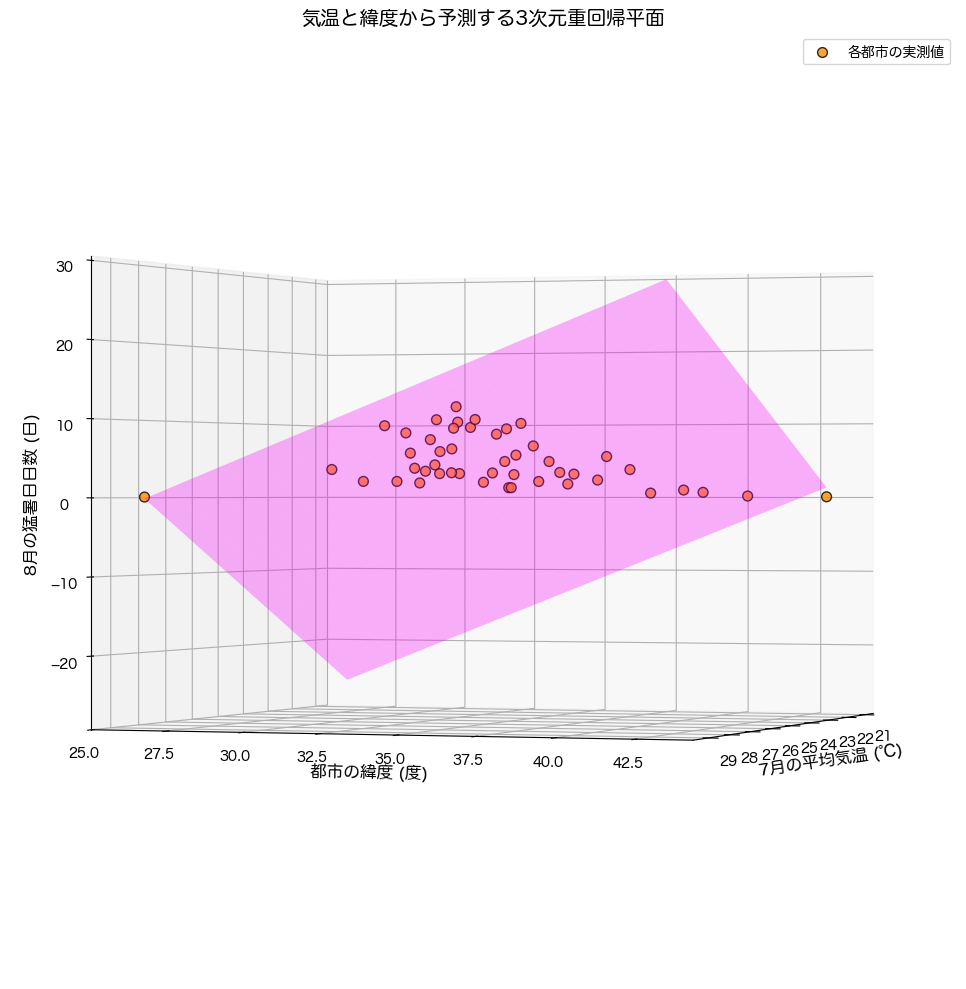

In [28]:
def make_mlr_design_matrix(X_data):
    N = len(X_data)
    ones = np.ones((N, 1))
    return np.hstack([ones, X_data])

def pinv(X):
    return np.dot(np.linalg.inv(np.dot(X.T, X)), X.T)

# ==========================================
# 2. データの前処理（気温 と 緯度 の2つを抽出）
# ==========================================
df = pd.read_csv('tem.csv', header=1, encoding='utf-8-sig')
df.columns = df.columns.str.strip()

df_july = df[df['月・年'] == '07月'].copy()
df_august = df[df['月・年'] == '08月'].copy()

# 今回は「平均気温」と、地理的要因である「緯度」を使用、ここを変更する
df_july = df_july.rename(columns={'平均気温': '7月_平均気温', '緯度': '都市_緯度'})

df_merge = pd.merge(
    df_july[['都道府県', '市', '7月_平均気温', '都市_緯度']],
    df_august[['都道府県', '市', '日最高気温35℃以上の日数']],
    on=['都道府県', '市']
)

cols = ['7月_平均気温', '都市_緯度', '日最高気温35℃以上の日数']
for col in cols:
    df_merge[col] = pd.to_numeric(df_merge[col], errors='coerce')

df_clean = df_merge.dropna(subset=cols)

# X1:気温, X2:緯度 を2次元配列にする
X_data = df_clean[['7月_平均気温', '都市_緯度']].values
y = df_clean['日最高気温35℃以上の日数'].values

# 重回帰分析の実行（最小二乗法）
Phi = make_mlr_design_matrix(X_data)
w = np.dot(pinv(Phi), y)

# 決定係数 (R2) の計算
yhat = np.dot(Phi, w)
ym = np.mean(y)
ssr = np.sum((yhat - ym)**2)
sst = np.sum((y - ym)**2)
R2 = ssr / sst

print(f"【変数を『緯度』に変更した結果】")
print(f'w (回帰係数ベクトル) = \n{w}')
print(f'R2 (決定係数) = {R2 :.4f}')
print("-" * 50)

# ==========================================
# 3. 3次元グラフの描画
# ==========================================
fig = plt.figure(figsize=(10, 10), tight_layout=True)
ax = fig.add_subplot(111, projection='3d')

# 実測値の3次元散布図（X:気温、Y:緯度、Z:猛暑日）
ax.scatter(X_data[:, 0], X_data[:, 1], y, color='darkorange', alpha=0.8, edgecolors='black', s=50, label='各都市の実測値')

# 予測の「回帰平面」を描くための格子点を生成
x1_range = np.linspace(X_data[:, 0].min(), X_data[:, 0].max(), 20)
x2_range = np.linspace(X_data[:, 1].min(), X_data[:, 1].max(), 20)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)

# 格子点に対するAIの予測値（Z軸の高さ）を平面の方程式から計算
# z = w0 + w1*x1 + w2*x2
Z_grid = w[0] + w[1] * X1_grid + w[2] * X2_grid

# 回帰平面を半透明のメッシュでプロット
ax.plot_surface(X1_grid, X2_grid, Z_grid, color='magenta', alpha=0.3, shade=True)

# 軸ラベルの設定
ax.set_xlabel('7月の平均気温 (℃)', fontsize=12)
ax.set_ylabel('都市の緯度 (度)', fontsize=12)
ax.set_zlabel('8月の猛暑日日数 (日)', fontsize=12)
ax.set_title('気温と緯度から予測する3次元重回帰平面', fontsize=14)
ax.legend()

ax.view_init(elev=0, azim=20)

plt.show()

SVR

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import KFold

# 日本語フォントの設定
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Hiragino Maru Gothic Pro', 'Hiragino Sans', 'Yu Gothic', 'Meirio', 'MS Gothic', 'Noto Sans CJK JP']

使用カーネル: rbf
R2 (決定係数) = 0.8883


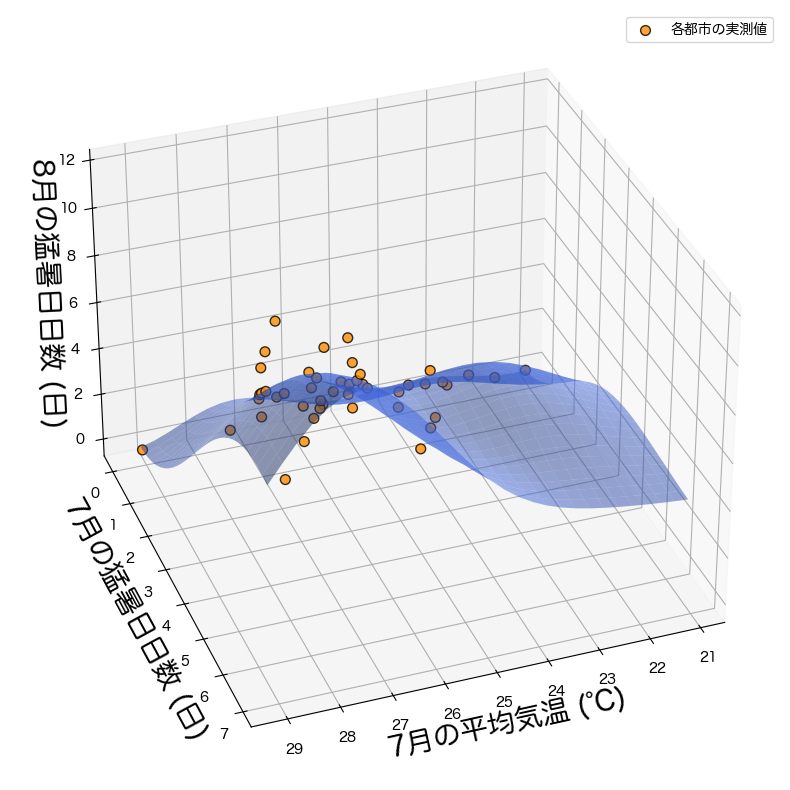

In [30]:
# ==========================================
# 1. データの前処理（7月の平均気温 と 7月の猛暑日日数を抽出）
# ==========================================
df = pd.read_csv('tem.csv', header=1, encoding='utf-8-sig')
df.columns = df.columns.str.strip()

df_july = df[df['月・年'] == '07月'].copy().rename(columns={'平均気温': '7月_平均気温', '日最高気温35℃以上の日数': '7月_猛暑日日数'})
df_august = df[df['月・年'] == '08月'].copy()

df_merge = pd.merge(
    df_july[['都道府県', '市', '7月_平均気温', '7月_猛暑日日数']],
    df_august[['都道府県', '市', '日最高気温35℃以上の日数']],
    on=['都道府県', '市'],
    suffixes=('', '_8月')
)

cols = ['7月_平均気温', '7月_猛暑日日数', '日最高気温35℃以上の日数']
for col in cols:
    df_merge[col] = pd.to_numeric(df_merge[col], errors='coerce')

df_clean = df_merge.dropna(subset=cols)

# X_data: 特徴量, y: 目的変数
X_data = df_clean[['7月_平均気温', '7月_猛暑日日数']].values
y = df_clean['日最高気温35℃以上の日数'].values

# ==========================================
# 2. データの標準化
# ==========================================
# SVMはデータのスケールに敏感なので、平均0・標準偏差1に変換する
X_mean = X_data.mean(axis=0)
X_std = X_data.std(axis=0)
X_scaled = (X_data - X_mean) / X_std

# ==========================================
# 3. サポートベクター回帰（SVR）の定義と学習
# ==========================================
# 基礎ゼミ資料のようにパラメータを定義
svm_C = 8    # 誤りに対するペナルティ（大きくすると複雑な境界になる）
svm_kernel = 'rbf'  # 非線形カーネル（RBF: ガウスカーネル）を指定し、曲面を作る
svm_gamma = 0.5 # カーネルの広がり具合
svm_epsilon = 0.0009765625   # ★SVR特有：「この誤差（±0.5日）以内なら無視する」というチューブの幅

# SVRモデルの作成と学習
clf = svm.SVR(C=svm_C, kernel=svm_kernel, gamma=svm_gamma, epsilon=svm_epsilon)
clf.fit(X_scaled, y)

# 予測と決定係数(R2)の計算
yhat = clf.predict(X_scaled)

ym = np.mean(y)
ssr = np.sum((yhat - ym)**2)
sst = np.sum((y - ym)**2)
R2 = clf.score(X_scaled, y)

print(f"使用カーネル: {svm_kernel}")
print(f"R2 (決定係数) = {R2 :.4f}")

# ==========================================
# 4. 3次元グラフ（非線形SVR曲面）の描画
# ==========================================
fig = plt.figure(figsize=(10, 8), tight_layout=True)
ax = fig.add_subplot(111, projection='3d')

# 実測値のプロット
ax.scatter(X_data[:, 0], X_data[:, 1], y, color='darkorange', alpha=0.8, edgecolors='black', s=50, label='各都市の実測値')

# 予測曲面を描くための格子点生成（元のスケールで作成）
x1_range = np.linspace(X_data[:, 0].min(), X_data[:, 0].max(), 30)
x2_range = np.linspace(X_data[:, 1].min(), X_data[:, 1].max(), 30)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)

# 格子点も同じように「標準化」してからSVRに予測させる
X_grid_flat = np.c_[X1_grid.ravel(), X2_grid.ravel()]
X_grid_scaled = (X_grid_flat - X_mean) / X_std
Z_grid_flat = clf.predict(X_grid_scaled)
Z_grid = Z_grid_flat.reshape(X1_grid.shape)

# SVRの予測曲面をプロット
ax.plot_surface(X1_grid, X2_grid, Z_grid, color='royalblue', alpha=0.5, shade=True)

ax.set_xlabel('7月の平均気温 (℃)', fontsize=20)
ax.set_ylabel('7月の猛暑日日数 (日)', fontsize=20)
ax.set_zlabel('8月の猛暑日日数 (日)', fontsize=20)
ax.legend()
#C: 8.0, epsilon: 0.0009765625, gamma: 0.5
ax.view_init(elev=33, azim=70)
plt.show()

【パラメータ探索（グリッドサーチ）結果】
カーネル: linear | C:   0.1 | epsilon: 0.1 | R2 = 0.8264
カーネル: linear | C:   0.1 | epsilon: 0.5 | R2 = 0.8143
カーネル: linear | C:   0.1 | epsilon: 1.0 | R2 = 0.7714
カーネル: linear | C:   1.0 | epsilon: 0.1 | R2 = 0.8594
カーネル: linear | C:   1.0 | epsilon: 0.5 | R2 = 0.8585
カーネル: linear | C:   1.0 | epsilon: 1.0 | R2 = 0.8572
カーネル: linear | C:  10.0 | epsilon: 0.1 | R2 = 0.8559
カーネル: linear | C:  10.0 | epsilon: 0.5 | R2 = 0.8566
カーネル: linear | C:  10.0 | epsilon: 1.0 | R2 = 0.8574
カーネル: linear | C:  50.0 | epsilon: 0.1 | R2 = 0.8559
カーネル: linear | C:  50.0 | epsilon: 0.5 | R2 = 0.8566
カーネル: linear | C:  50.0 | epsilon: 1.0 | R2 = 0.8574
カーネル: linear | C: 100.0 | epsilon: 0.1 | R2 = 0.8559
カーネル: linear | C: 100.0 | epsilon: 0.5 | R2 = 0.8566
カーネル: linear | C: 100.0 | epsilon: 1.0 | R2 = 0.8574
カーネル: rbf    | C:   0.1 | epsilon: 0.1 | R2 = 0.2561
カーネル: rbf    | C:   0.1 | epsilon: 0.5 | R2 = 0.2799
カーネル: rbf    | C:   0.1 | epsilon: 1.0 | R2 = 0.2972
カーネル: rbf    | C:   1.0 |

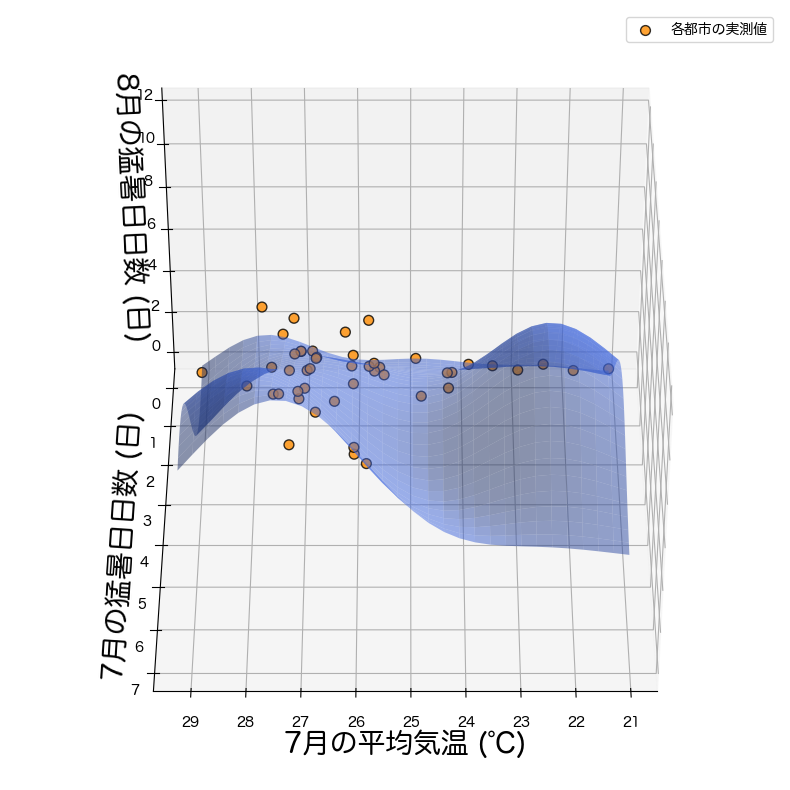

In [31]:
# ==========================================
# 3. パラメータの自動チューニング（実験セクション）
# ==========================================
# ★ここで試したいパラメータの候補をリスト形式で複数設定します！
# 好きな数字や文字を追加・変更して遊んでみてください。
test_kernels = ['linear', 'rbf']  # カーネル（直線、ガウス曲面、多項式曲面）
test_Cs = [0.1, 1.0, 10.0, 50.0, 100.0]   # 誤りへの厳しさ（大きいほど過学習しやすい）
test_epsilons = [0.1, 0.5, 1.0]           # チューブの幅（ノイズを無視する幅）

print("【パラメータ探索（グリッドサーチ）結果】")
best_R2 = -100
best_params = {}
best_clf = None

# for文を使って、上で設定したパラメータの全組み合わせを総当たりでテストします
for kernel in test_kernels:
    for c_val in test_Cs:
        for eps in test_epsilons:
            
            # SVRモデルの作成と学習
            clf = svm.SVR(C=c_val, kernel=kernel, gamma='scale', epsilon=eps)
            clf.fit(X_scaled, y)
            
            R2 = clf.score(X_scaled, y)
            
            # 各組み合わせのスコアを出力
            print(f"カーネル: {kernel: <6} | C: {c_val: >5} | epsilon: {eps: >3} | R2 = {R2:.4f}")
            
            # もし過去の最高精度（best_R2）を上回ったら、そのモデルと設定を記憶しておく
            if R2 > best_R2:
                best_R2 = R2
                best_params = {'kernel': kernel, 'C': c_val, 'epsilon': eps}
                best_clf = clf

print()
print(f"1番いいパラメータ {best_params}")


# ==========================================
# 4. 3次元グラフ（最高精度のモデルを使って自動描画）
# ==========================================
fig = plt.figure(figsize=(10, 8), tight_layout=True)
ax = fig.add_subplot(111, projection='3d')

# 実測値のプロット
ax.scatter(X_data[:, 0], X_data[:, 1], y, color='darkorange', alpha=0.8, edgecolors='black', s=50, label='各都市の実測値')

# 予測曲面を描くための格子点生成
x1_range = np.linspace(X_data[:, 0].min(), X_data[:, 0].max(), 30)
x2_range = np.linspace(X_data[:, 1].min(), X_data[:, 1].max(), 30)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)

# 格子点を標準化して「最高精度を出したモデル（best_clf）」に予測させる
X_grid_flat = np.c_[X1_grid.ravel(), X2_grid.ravel()]
X_grid_scaled = (X_grid_flat - X_mean) / X_std
Z_grid_flat = best_clf.predict(X_grid_scaled)
Z_grid = Z_grid_flat.reshape(X1_grid.shape)

# SVRの予測曲面をプロット（見えやすいように色分け）
if best_params['kernel'] == 'linear':
    surf_color = 'limegreen' # 直線の場合は緑系
else:
    surf_color = 'royalblue' # 曲線の場合は青系

ax.plot_surface(X1_grid, X2_grid, Z_grid, color=surf_color, alpha=0.5, shade=True)

ax.set_xlabel('7月の平均気温 (℃)', fontsize=20)
ax.set_ylabel('7月の猛暑日日数 (日)', fontsize=20)
ax.set_zlabel('8月の猛暑日日数 (日)', fontsize=20)

ax.legend()

ax.view_init(elev=40, azim=90) # 全体が見渡しやすい角度
plt.show()

交差検証

猛暑日データを使ってSVR_Linearの学習と交差検証を行っていきます．

交差検証による平均R2（決定係数）は 0.7392 です．


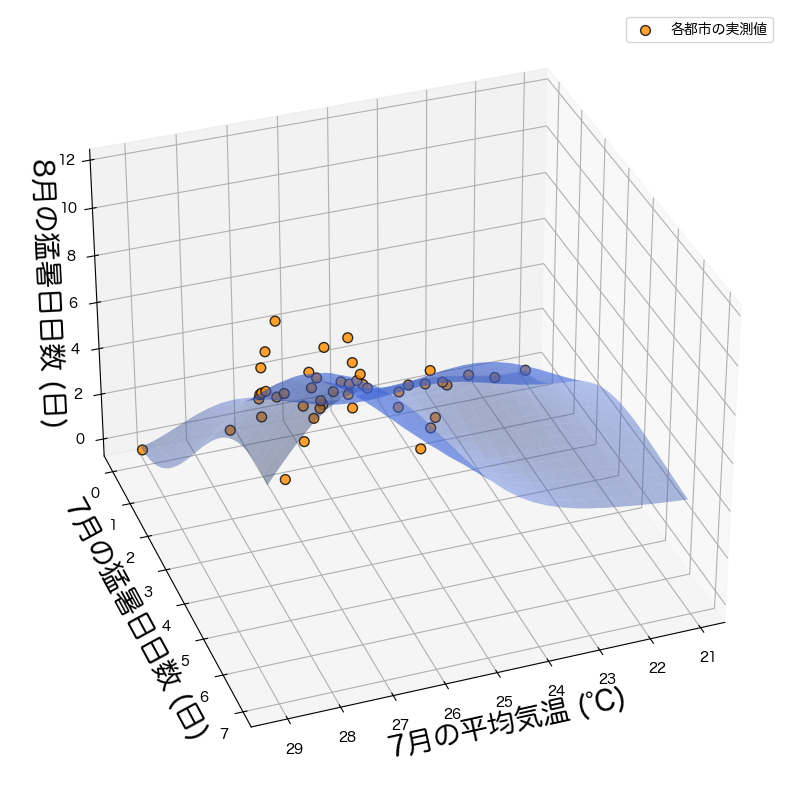

In [32]:
# ==========================================
# 1. 識別手法（回帰）の学習とテスト
# ==========================================
def test_regressor(clf, data, label, n_splits=5):
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=2026)
    r2_scores = []
    
    for train, test in cv.split(data):
        data_train, data_test = data[train], data[test]
        label_train, label_test = label[train], label[test]

        clf.fit(data_train, label_train)
        label_pred = clf.predict(data_test)
            
        ym = np.mean(label_test)
        ssr = np.sum((label_pred - ym)**2)
        sst = np.sum((label_test - ym)**2)
        r2 = clf.score(data_test, label_test)
        r2_scores.append(r2)

    return np.mean(r2_scores)

# ==========================================
# 2. 3次元グラフの描画関数
# ==========================================
def draw_reg_graph(clf, data, label, X_mean, X_std, filename=''):
    fig = plt.figure(figsize=(10, 8), tight_layout=True)
    ax = fig.add_subplot(111, projection='3d')

    data_orig = (data * X_std) + X_mean
    ax.scatter(data_orig[:, 0], data_orig[:, 1], label, color='darkorange', alpha=0.8, edgecolors='black', s=50, label='各都市の実測値')

    x1_range = np.linspace(data_orig[:, 0].min(), data_orig[:, 0].max(), 30)
    x2_range = np.linspace(data_orig[:, 1].min(), data_orig[:, 1].max(), 30)
    X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)

    X_grid_flat = np.c_[X1_grid.ravel(), X2_grid.ravel()]
    X_grid_scaled = (X_grid_flat - X_mean) / X_std
    Z_grid_flat = clf.predict(X_grid_scaled)
    Z_grid = Z_grid_flat.reshape(X1_grid.shape)

    ax.plot_surface(X1_grid, X2_grid, Z_grid, color='royalblue', alpha=0.4, shade=True)

    ax.set_xlabel('7月の平均気温 (℃)', fontsize=20)
    ax.set_ylabel('7月の猛暑日日数 (日)', fontsize=20)  
    ax.set_zlabel('8月の猛暑日日数 (日)', fontsize=20)

    ax.view_init(elev=33, azim=70)
    ax.legend()

    plt.show()
    plt.close()

# ==========================================
# 3. まとめて学習・テスト・図示（★回帰式の表示ロジックを追加）
# ==========================================
def test_regression_method(dataname, methodname, clf, data, label, X_mean, X_std):
    print("====================================")
    print(dataname + "を使って" + methodname + "の学習と交差検証を行っていきます．")
    print("====================================")
    print("")
    
    outfile = dataname + '_' + methodname + '.png'
    
    # 1. 交差検証の実行
    mean_r2 = test_regressor(clf, data, label)
    print('交差検証による平均R2（決定係数）は %.4f です．' % (mean_r2))
    
    # 2. データ全体で最終フィッティング
    clf.fit(data, label)
    
    # 3. ★元のデータスケールに合わせた回帰式(方程式)の逆算と表示
    if hasattr(clf, 'coef_') and clf.kernel == 'linear':
        w_scaled = clf.coef_[0]      # 標準化空間での傾き [w1, w2]
        b_scaled = clf.intercept_[0] # 標準化空間での切片
        
        # 元のスケールに戻すための数学的な補正
        w_orig = w_scaled / X_std
        b_orig = b_scaled - np.sum((w_scaled * X_mean) / X_std)
        
        print(f"y = {b_orig:.4f} + ({w_orig[0]:.4f} * x1) + ({w_orig[1]:.4f} * x2)")
        print("\n[記号の意味]")
        print("  y  : 8月の猛暑日日数 (予測値)")
        print("  x1 : 7月の平均気温 (℃)")
        print("  x2 : 7月の猛暑日日数 (日)")
        print("-" * 50)
    
    # 4. グラフ描画
    draw_reg_graph(clf, data, label, X_mean, X_std, filename=outfile)

# ==========================================
# 4. データの前処理と実行（メイン処理）
# ==========================================
df = pd.read_csv('tem.csv', header=1, encoding='utf-8-sig')
df.columns = df.columns.str.strip()

df_july = df[df['月・年'] == '07月'].copy().rename(columns={'平均気温': '7月_平均気温', '日最高気温35℃以上の日数': '7月_猛暑日日数'})
df_august = df[df['月・年'] == '08月'].copy()

df_merge = pd.merge(
    df_july[['都道府県', '市', '7月_平均気温', '7月_猛暑日日数']],
    df_august[['都道府県', '市', '日最高気温35℃以上の日数']],
    on=['都道府県', '市'],
    suffixes=('', '_8月')
)

cols = ['7月_平均気温', '7月_猛暑日日数', '日最高気温35℃以上の日数']
for col in cols:
    df_merge[col] = pd.to_numeric(df_merge[col], errors='coerce')

df_clean = df_merge.dropna(subset=cols)

X_data = df_clean[['7月_平均気温', '7月_猛暑日日数']].values
y = df_clean['日最高気温35℃以上の日数'].values

# 標準化
X_mean = X_data.mean(axis=0)
X_std = X_data.std(axis=0)
X_scaled = (X_data - X_mean) / X_std

# SVRモデルの定義（linear）
clf_svr = svm.SVR(C=8, kernel='rbf', epsilon=0.0009765625)

# 実行
test_regression_method("猛暑日データ", "SVR_Linear", clf_svr, X_scaled, y, X_mean, X_std)

In [33]:
from sklearn.model_selection import GridSearchCV
import time

# ==========================================
# 3. SVRハイパーパラメータの高速最適化（金子研メソッド）
# ==========================================
print("【金子研究室の手法に基づくSVRパラメータの高速最適化を開始】")
start_time = time.time()

# 1. 2の累乗によるパラメータ候補の設定
svr_cs = 2 ** np.arange(-5, 11, dtype=float)         # Cの候補
svr_epsilons = 2 ** np.arange(-10, 1, dtype=float)   # epsilonの候補
svr_gammas = 2 ** np.arange(-20, 11, dtype=float)    # gammaの候補

# 2. グラム行列の分散最大化による gamma の最適化
variance_of_gram_matrix = []
for svr_gamma in svr_gammas:
    # グラム行列を計算し、その分散を求める
    gram_matrix = np.exp(-svr_gamma * ((X_scaled[:, np.newaxis] - X_scaled) ** 2).sum(axis=2))
    variance_of_gram_matrix.append(gram_matrix.var(ddof=1))

# 分散が最大となる gamma を取得
optimal_gamma = svr_gammas[np.where(variance_of_gram_matrix == np.max(variance_of_gram_matrix))[0][0]]
print(f"[Step 1] グラム行列の分散最大化により最適化された gamma: {optimal_gamma}")

# 3. 交差検証による epsilon の最適化（Cは一時的に3で固定）
print("[Step 2] 交差検証による epsilon の最適化中...")
svr_model_eps = GridSearchCV(svm.SVR(kernel='rbf', C=3, gamma=optimal_gamma), 
                             {'epsilon': svr_epsilons}, cv=5, n_jobs=-1)
svr_model_eps.fit(X_scaled, y)
optimal_epsilon = svr_model_eps.best_params_['epsilon']

# 4. 交差検証による C の最適化
print("[Step 3] 交差検証による C の最適化中...")
svr_model_c = GridSearchCV(svm.SVR(kernel='rbf', epsilon=optimal_epsilon, gamma=optimal_gamma), 
                           {'C': svr_cs}, cv=5, n_jobs=-1)
svr_model_c.fit(X_scaled, y)
optimal_c = svr_model_c.best_params_['C']

elapsed_time = time.time() - start_time
print("-" * 50)
print(f"✅ 最適化完了！ (計算時間: {elapsed_time:.2f}秒)")
print(f"👑 【最強パラメータ】 C: {optimal_c}, epsilon: {optimal_epsilon}, gamma: {optimal_gamma}")

# 5. 最強パラメータで最終的なSVRモデルを構築
best_clf = svm.SVR(kernel='rbf', C=optimal_c, epsilon=optimal_epsilon, gamma=optimal_gamma)
best_clf.fit(X_scaled, y)

# 予測と自己ベストR2の計算（確認用）
R2_best = best_clf.score(X_scaled, y)
print(f"自己ベスト R2スコア: {R2_best:.4f}")
print("-" * 50)

【金子研究室の手法に基づくSVRパラメータの高速最適化を開始】
[Step 1] グラム行列の分散最大化により最適化された gamma: 0.5
[Step 2] 交差検証による epsilon の最適化中...
[Step 3] 交差検証による C の最適化中...
--------------------------------------------------
✅ 最適化完了！ (計算時間: 2.25秒)
👑 【最強パラメータ】 C: 8.0, epsilon: 0.0009765625, gamma: 0.5
自己ベスト R2スコア: 0.8883
--------------------------------------------------
